Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

plt.rcParams['figure.figsize'] = (10, 6)

Load Dataset

In [3]:
# Load dataset
data_cancer = load_breast_cancer()

df = pd.DataFrame(data_cancer.data, columns=data_cancer.feature_names)
df['target'] = data_cancer.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Cek Info Data

In [5]:
print("Info Dataset:")
df.info()

print("\nJumlah Missing Value:")
print(df.isnull().sum())

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness e

Cek Sebaran Kelas Target

In [6]:
print("Nama kelas:", data_cancer.target_names)
df['target'].value_counts()

Nama kelas: ['malignant' 'benign']


,count
target,
1,357
0,212


Split Data Training & Testing

In [7]:
# Pisahkan Fitur (X) dan Label (y)
X = data_cancer.data
y = data_cancer.target

print("Shape X:", X.shape)
print("Shape y:", y.shape)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Shape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)

Shape X: (569, 30)
Shape y: (569,)
Shape X_train: (455, 30)
Shape X_test : (114, 30)


Standardisasi Data

In [8]:
# Standardisasi (mean=0, std=1)
scaler = StandardScaler()

# Fit pada training, transform pada training & test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Cek hasil scaling baris pertama
print(X_train_scaled[0])

[-1.07200079e+00 -6.58424598e-01 -1.08808010e+00 -9.39273639e-01
 -1.35939882e-01 -1.00871795e+00 -9.68358632e-01 -1.10203235e+00
  2.81062120e-01 -1.13231479e-01 -7.04860874e-01 -4.40938351e-01
 -7.43948977e-01 -6.29804931e-01  7.48061001e-04 -9.91572979e-01
 -6.93759567e-01 -9.83284458e-01 -5.91579010e-01 -4.28972052e-01
 -1.03409427e+00 -6.23497432e-01 -1.07077336e+00 -8.76534437e-01
 -1.69982346e-01 -1.03883630e+00 -1.07899452e+00 -1.35052668e+00
 -3.52658049e-01 -5.41380026e-01]


Model SVM Tanpa PCA

In [9]:
# Model SVM tanpa PCA
svm_no_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_no_pca.fit(X_train_scaled, y_train)

# Prediksi
y_pred_no_pca = svm_no_pca.predict(X_test_scaled)
acc_no_pca = accuracy_score(y_test, y_pred_no_pca)

print("Akurasi SVM tanpa PCA:", acc_no_pca)
print("\nClassification Report (tanpa PCA):")
print(classification_report(y_test, y_pred_no_pca, target_names=data_cancer.target_names))

Akurasi SVM tanpa PCA: 0.9824561403508771

Classification Report (tanpa PCA):
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



Penerapan PCA

In [10]:
# PCA dengan 3 komponen utama
pca = PCA(n_components=3)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Shape X_train_pca:", X_train_pca.shape)
print("Shape X_test_pca :", X_test_pca.shape)

Shape X_train_pca: (455, 3)
Shape X_test_pca : (114, 3)


Cek Variansi PCA

Explained Variance Ratio: [0.44413492 0.18944618 0.09543356]
Total variansi (3 komponen): 0.7290146639367362


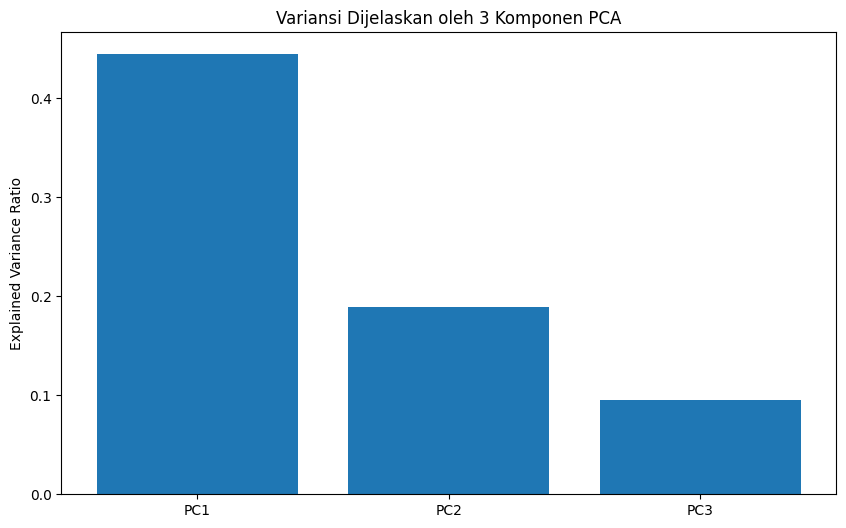

In [11]:
# Variansi yang dijelaskan tiap komponen
explained_var = pca.explained_variance_ratio_

print("Explained Variance Ratio:", explained_var)
print("Total variansi (3 komponen):", explained_var.sum())

# Grafik Batang
plt.figure()
plt.bar(['PC1', 'PC2', 'PC3'], explained_var)
plt.ylabel('Explained Variance Ratio')
plt.title('Variansi Dijelaskan oleh 3 Komponen PCA')
plt.show()

Model SVM Dengan PCA

In [12]:
# Model SVM dengan PCA
svm_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_pca.fit(X_train_pca, y_train)

# Prediksi
y_pred_pca = svm_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

print("Akurasi SVM dengan PCA (3 komponen):", acc_pca)
print("\nClassification Report (dengan PCA):")
print(classification_report(y_test, y_pred_pca, target_names=data_cancer.target_names))

Akurasi SVM dengan PCA (3 komponen): 0.9473684210526315

Classification Report (dengan PCA):
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



Visualisasi 3D

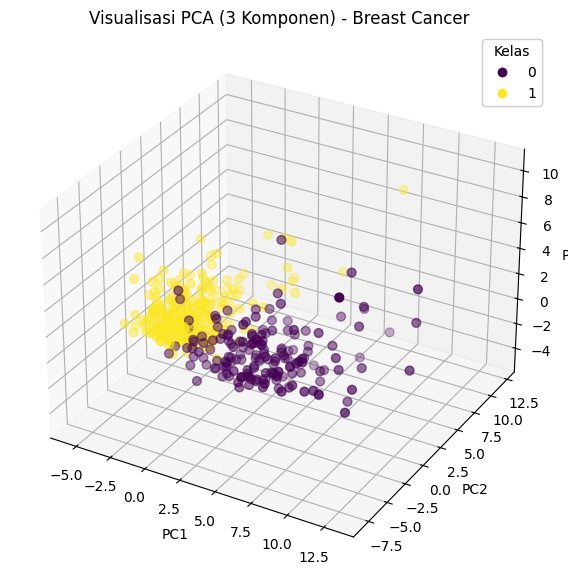

In [13]:
# Visualisasi 3D PCA
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    X_train_pca[:, 2],
    c=y_train,
    s=40,
    cmap='viridis'
)

ax.set_title('Visualisasi PCA (3 Komponen) - Breast Cancer')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

# Legend
legend1 = ax.legend(*scatter.legend_elements(), title="Kelas")
ax.add_artist(legend1)

plt.show()

Kesimpulan Perbandingan

                         Model  Jumlah Fitur   Akurasi  Variansi Total PCA
0                SVM Tanpa PCA            30  0.982456                 NaN
1  SVM Dengan PCA (3 Komponen)             3  0.947368            0.729015


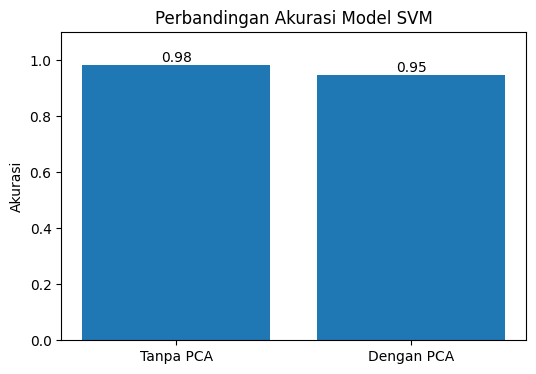

In [14]:
# Tabel Perbandingan
comparison = pd.DataFrame({
    'Model': ['SVM Tanpa PCA', 'SVM Dengan PCA (3 Komponen)'],
    'Jumlah Fitur': [X_train_scaled.shape[1], X_train_pca.shape[1]],
    'Akurasi': [acc_no_pca, acc_pca],
    'Variansi Total PCA': [None, explained_var.sum()]
})

print(comparison)

# Grafik Perbandingan Akurasi
plt.figure(figsize=(6, 4))
plt.bar(['Tanpa PCA', 'Dengan PCA'], [acc_no_pca, acc_pca])
plt.title('Perbandingan Akurasi Model SVM')
plt.ylabel('Akurasi')
plt.ylim(0, 1.1)

# Menambah label angka di atas batang
for i, v in enumerate([acc_no_pca, acc_pca]):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center')

plt.show()